# **Analysis** | Website Performance Analysis for The Grammys

<div style="text-align: center;">
<img src="https://upload.wikimedia.org/wikipedia/en/thumb/0/01/The_Recording_Academy_logo.svg/2560px-The_Recording_Academy_logo.svg.png" alt="The Recording Academy Logo" width="320"/>
</div>
<br>

This analysis examines real web analytics data from both websites owned by The Recording Academy, better known as "the Grammys."

In 2022, the VP of Digital Strategy, Ray Starck, decided to split the websites into grammy.com and recordingacademy.com to better serve the Recording Academy's various audience needs. This analysis evaluates the impact of splitting the two websites and examines trends and audience behavior patterns.


## Data Dictionary

This analysis utilizes two primary data files: `grammys_live_web_analytics.csv` and `ra_live_web_analytics.csv`.

These files contain the following information:

- **date** - The date the data was confirmed. It is in `yyyy-mm-dd` format.
- **visitors** - The number of users who visited the website on that day.
- **pageviews** - The number of pages that all users viewed on the website.
- **sessions** - The total number of sessions on the website. A session is a group of user interactions with your website that take place within a given time frame. For example, a single session can contain multiple page views, events, and social interactions.
- **bounced_sessions** - The total number of bounced sessions on the website. A bounced session occurs when a visitor comes to the website and does not interact with any pages or links before leaving.
- **avg_session_duration_secs** - The average length for all session durations for all users that visited the website that day.
- **awards_week** - A binary flag indicating if the dates align with marketing campaigns before and after the Grammys award ceremony was held. This represents the major marketing push to maximize viewership for the event.
- **awards_night** - The actual night that the Grammy Awards event was held.

# Part 1: Data Exploration

This section provides a foundational understanding of the web analytics data for The Grammy Awards and The Recording Academy. By exploring the dataset first, we can make meaningful observations and informed decisions in subsequent analysis.

## Section 1: Environment Setup

To begin, import the required libraries: `pandas` for data manipulation and `plotly.express` for visualization.


In [4]:
# Import libraries
import pandas as pd
import plotly.express as px

## Section 2: Data Loading

The analysis begins by loading web analytics data from two primary sources: `grammy_live_web_analytics.csv` and `ra_live_web_analytics.csv`.

### Loading Grammy Website Data
Read the `grammy_live_web_analytics.csv` file and store it in a DataFrame named `full_df`.

### Loading Recording Academy Website Data
Read the `ra_live_web_analytics.csv` file and store it in a DataFrame named `rec_academy`.

### Initial Data Preview
Preview both DataFrames to understand the data structure and content.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Note: </strong>Data files are located in the datasets folder.
</span>
</div>

In [5]:
# Read in dataframes
full_df = pd.read_csv('datasets/grammy_live_web_analytics.csv')
rec_academy = pd.read_csv('datasets/ra_live_web_analytics.csv')

In [6]:
# Preview full_df dataframe
full_df.sample(5)

,date,visitors,pageviews,sessions,bounced_sessions,avg_session_duration_secs,awards_week,awards_night
1618,2021-06-07,18146,32246,19561,9785,89,0,0
1637,2021-06-26,13754,23432,14689,7530,80,0,0
734,2019-01-05,20213,37101,21798,9472,110,0,0
2156,2022-11-27,23161,64245,25493,10848,79,0,0
824,2019-04-05,16889,24098,17691,9366,70,0,0


In [7]:
# Preview rec_academy dataframe
rec_academy.sample(5)

,date,visitors,pageviews,sessions,bounced_sessions,avg_session_duration_secs,awards_week,awards_night
252,2022-10-11,3688,12321,4195,95,101,0,0
167,2022-07-18,1225,2876,1550,1044,126,0,0
286,2022-11-14,2383,8805,2791,282,108,0,0
145,2022-06-26,598,3180,724,511,276,0,0
451,2023-04-28,1661,5093,2177,1249,149,0,0


## Section 3: Traffic Pattern Analysis

The Grammy Awards are among the most prominent events in the global music industry. With such high visibility, understanding how this event impacts web traffic is crucial for strategic decision-making.

### Visualizing Daily Visitor Trends
Create a line chart showing the number of users on the site for every day in the `full_df` dataset.

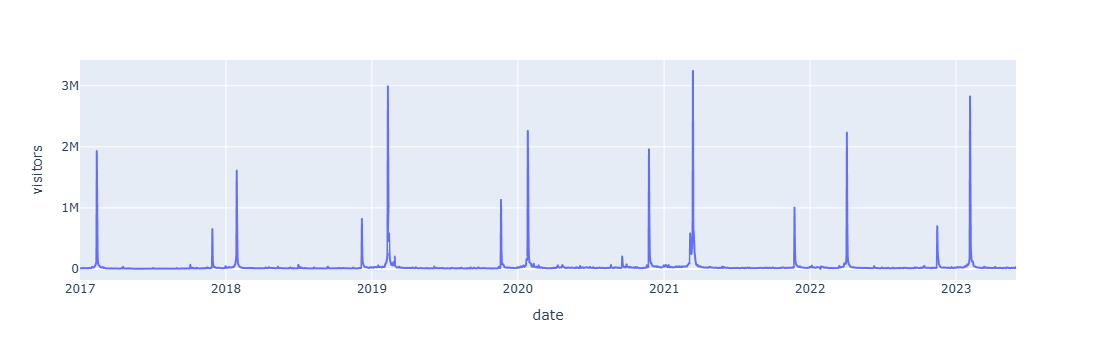

In [8]:
# Plot a line chart of the visitors on the site.
px.line(full_df, x = 'date', y = 'visitors')

### Traffic Spike Analysis
Analyze the visualization to identify when and why traffic spikes occur. Are the traffic spikes only aligning with "Show Night," or are there other events that could explain certain spikes in website traffic?

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Additional Analysis:</strong> Consider identifying specific lesser-known events (with exact dates) that might have caused significant increases in website traffic on grammys.com. External data sources could help confirm these trends.
  </span>
</div>

I notice that a smaller traffic spikes occur in around near the end of the year (Nov - Dec) and a significantly bigger spike around the start of the year (Jan - Apr). The reason of the big traffic spike occuring is because at the start of a year that's the time Grammy Awards ceremony usually happend. The smaller spike at the end of the year is becasue  of the Recording Academy announces Grammy nominations so they are in anticipation period. 

## Section 4: Awards Night Impact Analysis

To evaluate the impact of the Grammy Awards on user engagement, we compare average site traffic on the day of the ceremony versus all other days.

Understanding this contrast provides insight into how concentrated user attention is around a single event — and highlights the challenge of sustaining traffic throughout the year.

### Comparing Traffic Metrics
Use pandas `.groupby()` to compare the average daily website visitors on days when an award ceremony was held versus those when no awards ceremonies were held.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Implementation:</strong> Group by the <span style="font-family: monospace; color: #222;">awards_night</span> column.
</span>
</div>

In [9]:
# Average number of visitors on awards nights versus other nights
avg_visitor_night = full_df.groupby('awards_night').agg({'visitors': 'mean'})

award_night_avg = avg_visitor_night.loc[1, 'visitors']
normal_night_avg = avg_visitor_night.loc[0, 'visitors']

percent_increase = ((award_night_avg - normal_night_avg) / normal_night_avg) * 100

print(f"Award night has {percent_increase:.2f}% more traffic than a normal night.")
print(f"Award night has {(award_night_avg - normal_night_avg).round(0)} more visit than a normal night.")


Award night has 4190.41% more traffic than a normal night.
Award night has 1357202.0 more visit than a normal night.


### Findings
What does this comparison reveal about the difference in traffic between award ceremony days and regular days? How many more visitors does the Grammy Awards site receive on Show Night?


<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Key Business Insight: </strong>This represents The Recording Academy's biggest challenge: transforming a business that relies on the success of one event per year into one that continues to bring users back to the site year-round.
</span>
</div>

It reveals that the traffic between ceremony day and regular days that ceremony day has significantly way more visit than regular. On a Show Night there are on average 1357202 more visit than a normal night.

## Section 5: Pre- and Post-Split Data Segmentation

When The Recording Academy split its digital presence across two domains, grammy.com and recordingacademy.com, the data capture methodology for grammy.com remained unchanged. The way visitor data was collected for grammy.com stayed exactly the same before and after the split. 

To conduct a proper comparison, we need to separate the data from before the split (when both sites were combined) and after the split (when grammy.com data continued independently). The split occurred on February 1, 2022 (`2022-02-01`).

### Creating Segmented DataFrames

Create two new DataFrames:

1. `combined_site` should contain all data with dates before `2022-02-01`.

2. `grammys` should contain all data with dates on or after `2022-02-01`.

In [10]:
# Split the data to separate the full_df into two new dataframes.
# One for before the switch of the websites and one for after

combined_site = full_df[full_df['date'] < '2022-02-01']
grammys = full_df[full_df['date'] >= '2022-02-01']

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Best Practice: </strong>After creating these DataFrames, use the `.copy()` method to avoid warning messages from pandas when modifying them later.
</span>
</div>

In [11]:
# Pre-configured cell
# .copy() prevents pandas from printing a warning message
combined_site = combined_site.copy()
grammys = grammys.copy()

In [12]:
# Print the shape of the combined_site dataframe
combined_site.shape

(1857, 8)

<div style="border: 3px solid #f8c43e; background-color: #fff3c1; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
      Expected result: The <span style="font-family: monospace; color: #222;">combined_site</span> DataFrame contains <strong>1857</strong> rows and <strong>8</strong> columns.
  </span>
</div>



# Part 2: Key Metrics Analysis

The overall objective of this analysis is to evaluate whether splitting the website into two has improved user engagement. This section focuses on evaluating key metrics, such as bounce rate, pages per session, and average time on site, to determine if the split has had a positive or negative impact on how visitors interact with the site.

## Section 6: Pages Per Session Analysis

Pages per session is calculated by dividing the total `pageviews` by the total number of `sessions`. This metric measures how many unique pages a user views before leaving the site — a strong indicator of engagement.

### Calculating Pages Per Session

**Step 1:** Create a new list called `frames` containing each dataframe as an entry. For example, if there were 3 dataframes (`df1`, `df2`, `df3`), the code would look like:

```python
frames = [df1, df2, df3]
```

**Step 2:** For each frame in the frames list, create a new column called `pages_per_session`. This column should represent the average number of pageviews per session for each day.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Implementation:</strong> Divide the <span style="font-family: monospace; color: #222;">pageviews</span> column by the <span style="font-family: monospace; color: #222;">sessions</span> column.
</span>
</div>

This can be achieved using the following template:

```python
frame['new_col'] = frame['col_A'] / frame['col_B']
```



In [13]:
# Create the `pages_per_session` column for all 3 dataframes.
frames = [combined_site, grammys, rec_academy]
for frame in frames:
    frame['pages_per_session'] = frame['pageviews'] / frame['sessions']


### Visualizing Pages Per Session
Visualize the `pages_per_session` metric using a line chart for each site. This will produce 3 separate graphs.

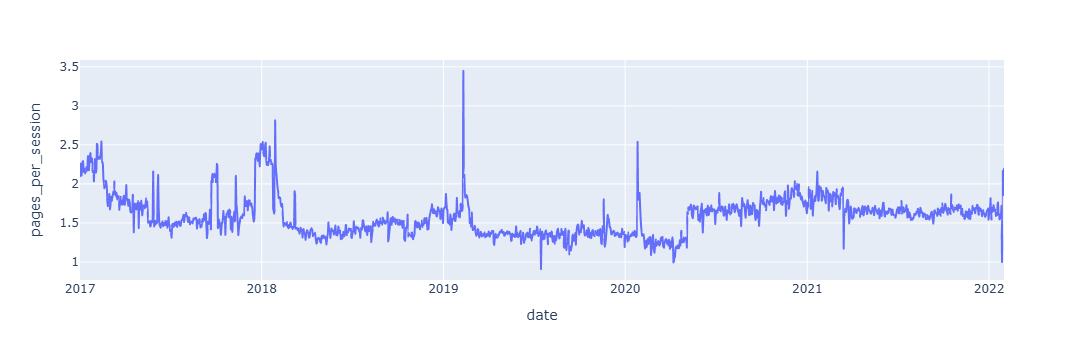

In [14]:
# combined_site graph
px.line(combined_site, x = 'date', y = 'pages_per_session')

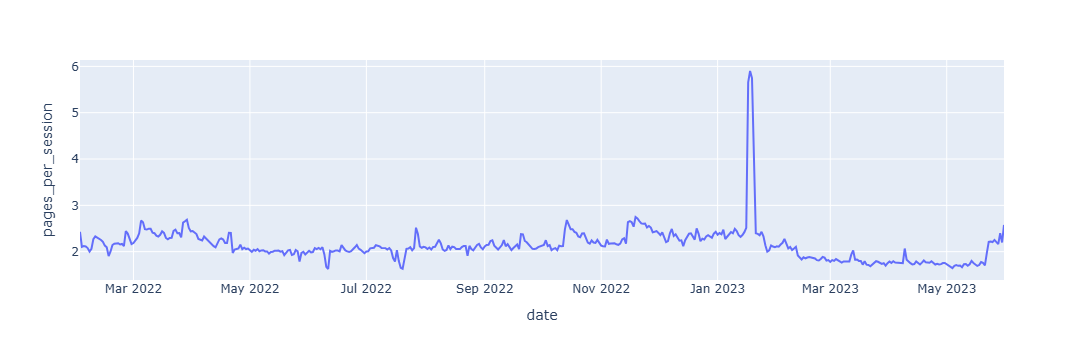

In [15]:
# grammys graph
px.line(grammys, x = 'date', y = 'pages_per_session')

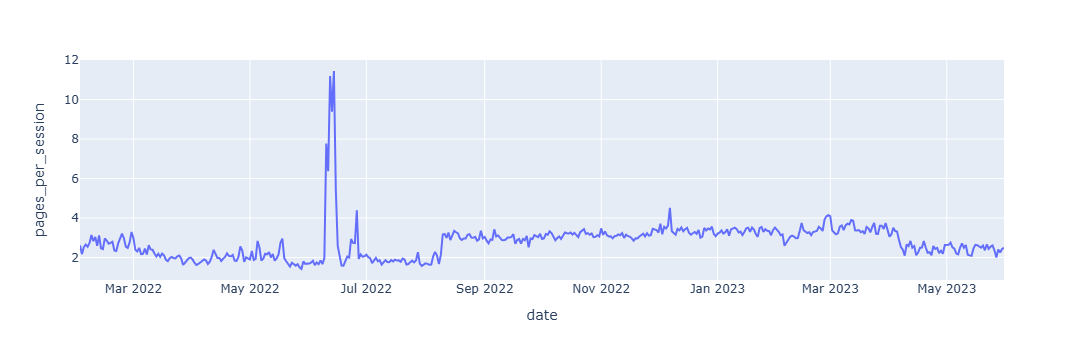

In [16]:
# rec_academy graph
px.line(rec_academy, x = 'date', y = 'pages_per_session')

### Interpretation
What does the `pages_per_session` metric suggest regarding the impact of the website split?

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Analysis Consideration:</strong> What does pages per session reveal about user engagement? How should changes in this metric after the website split be interpreted?
  </span>
</div>
<br>
<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Note: </strong>Any large spikes in the data that do not correspond with the Grammy Awards Ceremony can be attributed to abnormalities in the data collection process and should be excluded from the analysis.
</span>
</div>

## Section 7: Bounce Rate Analysis

Bounce rate is calculated by dividing the total `bounced_sessions` by the total number of `sessions`. Bounce rate is an important metric that calculates the percentage of users (sessions) that come to your site, never interact with the page, and leave. They are said to have "bounced" off your home page. It is a measure of how engaging your home page is with users.

### Creating Bounce Rate Function

Create a function called `bounce_rate` that:

1. Takes in a `dataframe` as input
2. Sums all values in the `bounced_sessions` column and stores it in a variable called `sum_bounced`
3. Sums all values in the `sessions` column and stores it in a variable called `sum_sessions`
4. Returns `100 * sum_bounced / sum_sessions`

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Implementation:</strong> Use the <span style="font-family: monospace; color: #222;">.sum()</span> function for both <span style="font-family: monospace; color: #222;">sum_bounced</span> and <span style="font-family: monospace; color: #222;">sum_sessions</span> calculations. Multiply by <strong>100</strong> to display as a percentage instead of a decimal.
</span>
</div>

In [17]:
def bounce_rate(dataframe):
    '''
    Calculates the bounce rate for visitors on the website.
    input: dataframe with bounced_sessions and sessions columns
    output: numeric value from bounce rate
    '''
    sum_bounced = dataframe['bounced_sessions'].sum()
    sum_sessions = dataframe['sessions'].sum()
    return 100 * sum_bounced / sum_sessions

### Calculating Bounce Rates Across Sites
Use the `frames` variable from Section 6 to loop over each website (represented by a dataframe) and calculate the bounce rate. Print the bounce rate for each site.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Implementation:</strong> Use <span style="font-family: monospace; color: #222;">bounce_rate(frame)</span> to calculate the bounce rate.
</span>
</div>

<br>

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Formatting Tip:</strong> To display numbers with 2 decimal places in an f-string, use: <span style="font-family: monospace; color: #222;">{value:.2f}</span>
  </span>
</div>

In [18]:
# Calculate the Bounce Rate for each site
# frames = [combined_site, grammys, rec_academy]
for frame in frames:
    print(bounce_rate(frame))


41.58442820704562
40.1586143332152
33.671923933914506


<div style="border: 3px solid #f8c43e; background-color: #fff3c1; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
  Expected results: The <span style="font-family: monospace; color: #222;">combined_site</span> and <span style="font-family: monospace; color: #222;">grammys</span> sites each have bounce rates in the low 40s. The <span style="font-family: monospace; color: #222;">rec_academy</span> has a bounce rate in the low 30s.
  </span>
</div>


### Average Time on Site Analysis
Calculate the `average_time_on_site` metric by computing the average of the `avg_session_duration_secs` column. Average Time on Site measures how engaging your website experience is for your users. The higher the number, the longer they stay on your page and engage with the content.

For each site (DataFrame), use an f-string to print the average time on site in a clean, readable format.

In [19]:
# Calculate the average of the avg_session_duration_secs
print(f"Average Time on combined site is {combined_site['avg_session_duration_secs'].mean()}")
print(f"Average Time on grammys is {grammys['avg_session_duration_secs'].mean()}")
print(f"Average Time on rec_academy is {rec_academy['avg_session_duration_secs'].mean()}")

Average Time on combined site is 102.85352719439958
Average Time on grammys is 82.98556701030928
Average Time on rec_academy is 128.50309278350517


### Metric Comparison
Which of these three metrics changed the most after the site split? What do these changes suggest about user behavior?

The metric that changed the most after the site split is record academy significant decrease in bounce rate which means who often show up to the record shows often stay and watch the content. It also reflect in the the average session duration of record showing being higher than before the split meaning people like the record show more than the grammy.

# Part 3: Demographics

Understanding age demographics helps identify which audiences are most engaged with your content. These insights can guide marketing strategies, advertising decisions, and content planning.

You’ll analyze the age demographics for both websites. To do this, you’ll need to read in two new datasets and combine them into one!



## Section 8: Age Demographics Analysis

The `grammys_age_demographics.csv` and `tra_age_demographics.csv` files each contain the following information:

- **age_group** - The age group range. e.g. `18-24` represents all visitors between the ages of 18 to 24 who visit the site.
- **pct_visitors** - The percentage of all website visitors that come from that specific age group.

### Loading Demographics Data
Read in the `grammys_age_demographics.csv` and `tra_age_demographics.csv` files and store them in dataframes named `age_grammys` and `age_tra`, respectively.

In [20]:
# Read in the files
age_grammys = pd.read_csv('datasets/grammys_age_demographics.csv')
age_tra = pd.read_csv('datasets/tra_age_demographics.csv')

In [21]:
# Preview the age_grammys file. the age_tra will look very similar.
age_grammys.head()


,age_group,pct_visitors
0,18-24,27.373210
1,25-34,24.129273
2,35-44,18.717867
3,45-54,13.568619
4,55-64,9.817036


### Labeling Data Sources
For each dataframe, create a new column called `website` whose value is the name of the website.
- The `age_grammys` values for `website` should all be `Grammys`
- The `age_tra` values for `website` should all be `Recording Academy`

In [22]:
# Label rows as 'Recording Academy'
age_tra['website'] = 'Recording Academy'

# Label rows as 'Grammys'
age_grammys['website'] = 'Grammys'

### Combining Demographics Data
Use the `pd.concat()` method to join these two datasets together. Store the result in a new variable called `age_df`.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Implementation:</strong> Place your dataframe variables inside a <strong>list</strong> first, then pass that list as input to <span style="font-family: monospace; color: #222;">pd.concat()</span>.
</div>

In [23]:
# Concatenate dataframes
age_df = pd.concat([age_tra, age_grammys], ignore_index=True)

# Preview combined data
age_df.shape

(12, 3)

<div style="border: 3px solid #f8c43e; background-color: #fff3c1; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
      Expected result: The combined DataFrame contains <strong>12</strong> rows and <strong>3</strong> columns.
  </span>
</div>

**D.** Create a bar chart of the `age_group` and `pct_visitors`. This chart should have, for each age group, one color for the Recording Academy and a different color for the Grammys.


<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>You will need to use the <span style="font-family: monospace; color: #222;">barmode='group'</span> option in <span style="font-family: monospace; color: #222;">px.bar()</span>. See the code snippet below to guide you.
</span>
</div>


```python
# Template for visualization
px.bar(dataframe, x='variable1', y='variable2', color='variable3', barmode='group')
```

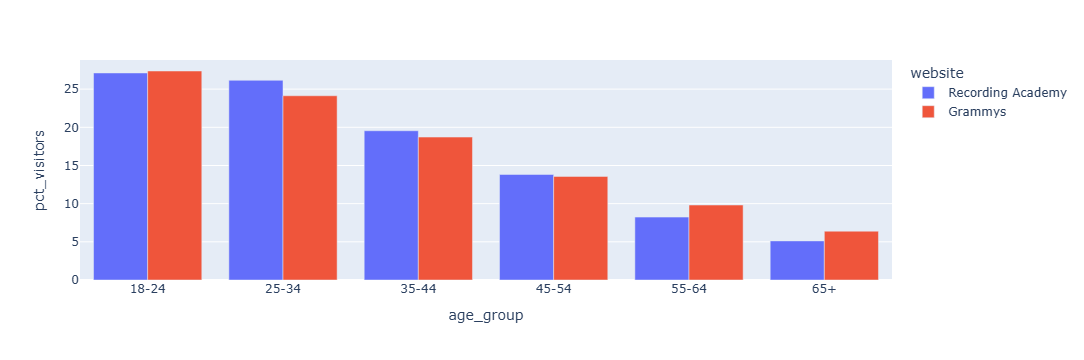

In [24]:
# age_group and pct_visitors bar chart
px.bar(age_df, x='age_group', y='pct_visitors', color='website', barmode='group')

### Demographics Comparison
What can you conclude about how the age demographics differ between the two websites?

The younger people of 18-54 seams to enjoy and visit Recording Academy more and the Grammys but the older group of 55-65+ enjoy and visit the Grammys more

# Part 4: Business Recommendations


## Task 9

Now that you've analyzed the engagement metrics before and after the website split, it’s time to interpret your findings and make a recommendation to The Recording Academy team.


**A.** Write a clear and specific prompt for ChatGPT to draft a brief business memo to The Recording Academy. Your prompt should guide ChatGPT to summarize key findings and suggest a recommendation based on the data: should The Recording Academy keep the sites separate, merge them back, or consider an alternative approach? Paste your prompt below.

As you can see The Recording Academy perform better in both boucing and people retention aspect, summarize these finding and do you have any recommendation based on the data given to you. Such as should The Recording Academy keep the sites separate, merge them back, or consider an alternative approach

### Evaluating AI Assistance
What did ChatGPT do well? Did it capture the key trends and insights? What was missing or inaccurate? Were any important details left out or misrepresented?

I think chatgpt do well in the aspect of conveying the message clearly and cleaning. The sentence are easy to read and understand. It captured the trends and put out statistic to support it.Nothing was missing, inaccurate much but it didn't include some of the terms meaning such as bounce so user without prior knowledge might get confuse. It did left out that contrast to The Recording Academy Grammy data suggest a opposite trend but that might not be the focus right now.

### Final Business Memo
Based on your reflection and evaluation of AI assistance, write your final, revised business memo below. This version should be polished and ready for presentation to Ray and The Recording Academy team.

After analyzing user engagement metrics before and after the website split, the data shows that The Recording Academy (TRA) website performs better in both bounce rate and user retention. Specifically, TRA has a lower bounce rate (≈33%) compared to Grammys.com (≈40%), meaning that fewer users leave without interacting with the site. Additionally, TRA visitors spend more time on average (≈128 seconds) compared to Grammys.com visitors (≈83 seconds), suggesting higher engagement and a stronger connection with the content.

Conversely, Grammys.com still experiences major traffic spikes during the awards season, showing it excels at attracting attention during event periods but struggles to maintain consistent engagement throughout the rest of the year. This contrast indicates that Grammys.com functions best as a short-term event hub, while TRA sustains long-term audience interest.

# Competitive Analysis: Grammys vs. American Music Awards

Ray and Harvey are both interested in seeing how the Grammys.com website compares to that of their main music award competitor, The American Music Awards (AMA). The dashboard below shows aggregated information about the performance of The AMA website for the months of April, May, and June of 2023.

The objective is to determine how the Grammys website is performing relative to The AMA website. In particular, we will examine device distribution and total visits over the same time span, leveraging information about Visit Duration, Bounce Rate, and Pages / Visit from the core analysis.

![](figs/TheAMAs.png)

**Key Metrics from AMA Dashboard:**
- **Total Visits** column represents the total number of visitors on the website during the timespan given.
- **Device Distribution** is the percentage share of visitors coming from Desktop users (PCs, Macs, etc.) and Mobile Users (iPhone, Android, etc.).
- Visitors on the AMA website spend on average 5 minutes and 53 seconds on the site and view 2.74 pages per visit (session).
- The AMA website has a bounce rate of 54.31%.

**A.** Load in the two files. The `desktop_users.csv` and `mobile_users.csv` files contain the users coming from desktop users and mobile users respectively.

Store them in variables named `desktop_users` and `mobile_users`

In [25]:
# Load in the data
desktop_users = pd.read_csv('datasets/desktop_users.csv')
mobile_users = pd.read_csv('datasets/mobile_users.csv')

In [26]:
# Preview the desktop_users file
desktop_users.head()

,date,segment,visitors
0,2022-02-01,Desktop Traffic,10195
1,2022-02-02,Desktop Traffic,10560
2,2022-02-03,Desktop Traffic,9935
3,2022-02-04,Desktop Traffic,8501
4,2022-02-05,Desktop Traffic,5424


In [27]:
# Preview mobile_users file
mobile_users.head()

,date,segment,visitors
0,2022-02-01,Mobile Traffic,23494
1,2022-02-02,Mobile Traffic,20234
2,2022-02-03,Mobile Traffic,22816
3,2022-02-04,Mobile Traffic,18592
4,2022-02-05,Mobile Traffic,13298


### Preparing Data for Analysis
Before joining the datasets, modify the column names to make them more descriptive.

For each dataframe, rename the `visitors` column to indicate which category it represents. For example, the `desktop_users` dataframe should have a column named `desktop_visitors` instead of `visitors`.

Additionally, drop the `segment` column since it is no longer needed.

In [28]:
# Change name of the visitors column to indicate which category it comes from
desktop_users = desktop_users.rename(columns={'visitors':'desktop_visitors'})
mobile_users = mobile_users.rename(columns={'visitors':'mobile_visitors'})
# desktop_users.head()
# mobile_users.head()

In [29]:
# Drop the segment column from each dataframe
desktop_users = desktop_users.drop(columns=['segment'])
mobile_users = mobile_users.drop(columns=['segment'])
# desktop_users.head()
# mobile_users.head()

### Merging Device Data
Join the two dataframes together in a new variable called `segment_df`.

In [30]:
# Join the two dataframes and preview the dataframe
segment_df = pd.merge(desktop_users, mobile_users, on='date', how='inner')
segment_df

,date,desktop_visitors,mobile_visitors
0,2022-02-01,10195,23494
1,2022-02-02,10560,20234
2,2022-02-03,9935,22816
3,2022-02-04,8501,18592
4,2022-02-05,5424,13298
...,...,...,...
510,2023-06-26,4302,7327
511,2023-06-27,5528,9491
512,2023-06-28,4928,9856
513,2023-06-29,5554,12881


### Calculating Device Distribution
Calculate the percentage share of users coming from desktop and mobile on the Grammys website.

**Step 1:** Create a new column, `total_visitors`, that is the sum of `desktop_visitors` and `mobile_visitors`.

In [31]:
# Create total_visitors column
segment_df['total_visitors'] = segment_df['desktop_visitors'] + segment_df['mobile_visitors']
segment_df

,date,desktop_visitors,mobile_visitors,total_visitors
0,2022-02-01,10195,23494,33689
1,2022-02-02,10560,20234,30794
2,2022-02-03,9935,22816,32751
3,2022-02-04,8501,18592,27093
4,2022-02-05,5424,13298,18722
...,...,...,...,...
510,2023-06-26,4302,7327,11629
511,2023-06-27,5528,9491,15019
512,2023-06-28,4928,9856,14784
513,2023-06-29,5554,12881,18435


<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Implementation:</strong> To calculate the percentage share, first filter the data to dates on or after `2023-04-01`. Then calculate the `sum` of desktop visitors and total visitors and divide those values. The percentage share of mobile visitors will be the value needed to reach 100%.
</span>
</div>



In [32]:
# Filter and calculate the percentage share
segment_df[segment_df['date'] >= '2023-04-01']
sum_d = segment_df['desktop_visitors'].sum()
total_v = segment_df['total_visitors'].sum()
# Use an f string to print each percentage to the screen
print(f"percentage share of users coming from desktop and mobile on the Grammys website are: {(sum_d/total_v) * 100}% and {100 - (sum_d/total_v) * 100}%")


percentage share of users coming from desktop and mobile on the Grammys website are: 26.425815761246113% and 73.57418423875389%


### Competitive Performance Assessment
How is the Grammys website performing relative to its competitor? What is the Grammys doing well, and what KPIs need improvement?

Based on the data, the Grammys website is performing competitively against the AMA, excelling in key areas of user retention and initial engagement. It is doing well by maintaining a significantly lower bounce rate (~40.16% vs. 54.31%) and driving users to view slightly more pages per session, which indicates stronger mobile engagement and effective content pathways. However, to close the gap with its competitor, the Grammys needs to improve on the critical KPI of average session duration; at just 83 seconds, it falls considerably short of the AMA's engaging 5 minutes and 53 seconds. Optimizing the desktop experience to capture a larger share of that audience could be a key strategy for increasing this time on site and further strengthening its overall performance